# Customer Churn Analysis

This notebook explores customer churn patterns, validates data quality, compares the provided train/test splits, and builds stakeholder-friendly churn segments for reporting.

## 1. Setup

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import pandas as pd

from customer_churn_analysis.analysis import (
    add_customer_buckets,
    build_data_quality_table,
    build_split_comparison_table,
    build_target_summary_table,
    correlation_table,
    numeric_feature_summary
)
from customer_churn_analysis.config import RAW_TEST_PATH, RAW_TRAIN_PATH
from customer_churn_analysis.data import (
    NUMERIC_COLUMNS,
    load_raw_dataset,
    prepare_and_persist_datasets,
    standardise_columns,
)
from customer_churn_analysis.visualization import (
    plot_churn_by_contract,
    plot_churn_by_subscription,
    plot_churn_rate_by_numeric_bins,
    plot_churn_rate_by_split,
    plot_correlation_heatmap,
    plot_numeric_distributions,
    plot_numeric_feature_by_churn,
    set_project_theme,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
set_project_theme()

## 2. Raw Data Preparation


In [2]:
raw_train_df = standardise_columns(load_raw_dataset(RAW_TRAIN_PATH, "train"))
raw_test_df = standardise_columns(load_raw_dataset(RAW_TEST_PATH, "test"))

for df in [raw_train_df, raw_test_df]:
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

raw_combined_df = pd.concat([raw_train_df, raw_test_df], ignore_index=True)

raw_train_df.shape, raw_test_df.shape, raw_combined_df.shape

((440833, 13), (64374, 13), (505207, 13))

In [3]:
raw_combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505207 entries, 0 to 505206
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            505206 non-null  float64
 1   age                    505206 non-null  float64
 2   gender                 505206 non-null  str    
 3   tenure_months          505206 non-null  float64
 4   usage_frequency        505206 non-null  float64
 5   support_calls          505206 non-null  float64
 6   payment_delay_days     505206 non-null  float64
 7   subscription_type      505206 non-null  str    
 8   contract_length        505206 non-null  str    
 9   total_spend            505206 non-null  float64
 10  last_interaction_days  505206 non-null  float64
 11  churn                  505206 non-null  float64
 12  source_split           505207 non-null  str    
dtypes: float64(9), str(4)
memory usage: 61.8 MB


## 3. Data Quality And Split Review


In [4]:
build_data_quality_table({"train": raw_train_df, "test": raw_test_df, "combined": raw_combined_df})

,dataset,rows,columns,duplicate_rows,total_missing_values,churn_rate
0,combined,505207,13,0,12,0.560
1,test,64374,13,0,0,0.470
2,train,440833,13,0,12,0.570


In [5]:
build_target_summary_table(raw_combined_df)

,source_split,customers,churn_rate
0,test,64374,0.470
1,train,440832,0.570


In [6]:
build_split_comparison_table(raw_combined_df).T

,0,1
source_split,test,train
age,41.970,39.370
tenure_months,31.990,31.260
usage_frequency,15.080,15.810
support_calls,5.400,3.600
payment_delay_days,17.130,12.970
total_spend,541.020,631.620
last_interaction_days,15.500,14.480


## 4. Data Cleaning

In [7]:
datasets = prepare_and_persist_datasets()
train_df = datasets["train"]
test_df = datasets["test"]
combined_df = add_customer_buckets(datasets["combined"])

train_df.shape, test_df.shape, combined_df.shape

((440832, 14), (64374, 14), (505206, 19))

## 5. Quick Data Orientation

The first pass below makes the cleaned schema, missingness, and broad feature distributions visible before we move into more structured analysis.

In [8]:
combined_df.head()

,customer_id,age,gender,tenure_months,usage_frequency,support_calls,payment_delay_days,subscription_type,contract_length,total_spend,last_interaction_days,churn,source_split,churn_label,tenure_band,payment_delay_band,usage_band,support_call_band,high_value_customer
0,2,30.000,Female,39.000,14.000,5.000,18.000,Standard,Annual,932.000,17.000,1,train,Churned,37-48,11-20,11-20,3-5,High Value
1,3,65.000,Female,49.000,1.000,10.000,8.000,Basic,Monthly,557.000,6.000,1,train,Churned,49-60,6-10,1-5,6-10,Mid Value
2,4,55.000,Female,14.000,4.000,6.000,18.000,Basic,Quarterly,185.000,3.000,1,train,Churned,13-24,11-20,1-5,6-10,Low Value
3,5,58.000,Male,38.000,21.000,7.000,7.000,Standard,Monthly,396.000,29.000,1,train,Churned,37-48,6-10,21-30,6-10,Low Value
4,6,23.000,Male,32.000,20.000,5.000,8.000,Basic,Monthly,617.000,20.000,1,train,Churned,25-36,6-10,11-20,3-5,Mid Value


In [9]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 505206 entries, 0 to 505205
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   customer_id            505206 non-null  Int64  
 1   age                    505206 non-null  float64
 2   gender                 505206 non-null  string 
 3   tenure_months          505206 non-null  float64
 4   usage_frequency        505206 non-null  float64
 5   support_calls          505206 non-null  float64
 6   payment_delay_days     505206 non-null  float64
 7   subscription_type      505206 non-null  string 
 8   contract_length        505206 non-null  string 
 9   total_spend            505206 non-null  float64
 10  last_interaction_days  505206 non-null  float64
 11  churn                  505206 non-null  Int64  
 12  source_split           505206 non-null  str    
 13  churn_label            505206 non-null  string 
 14  tenure_band            505206 non-null  string 

In [10]:
build_data_quality_table({"train": train_df, "test": test_df, "combined": combined_df})

,dataset,rows,columns,duplicate_rows,total_missing_values,churn_rate
0,combined,505206,19,0,0,0.560
1,test,64374,14,0,0,0.470
2,train,440832,14,0,0,0.570


## 6. Segment Analysis

The next sections turn the dataset into stakeholder-friendly customer segments so the retention story is easier to explain than raw feature values alone.

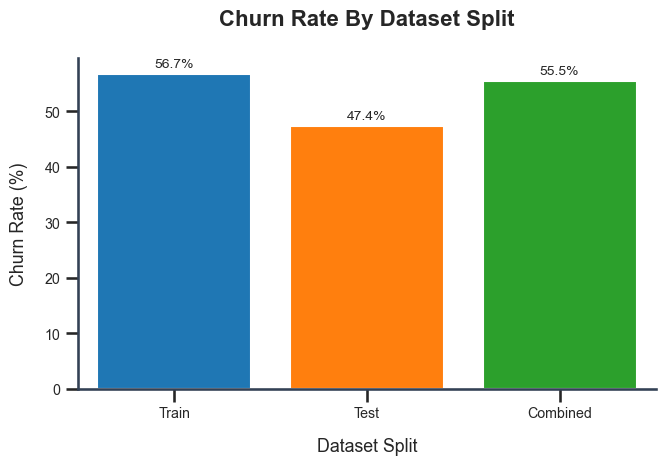

In [11]:
plot_churn_rate_by_split(raw_combined_df)

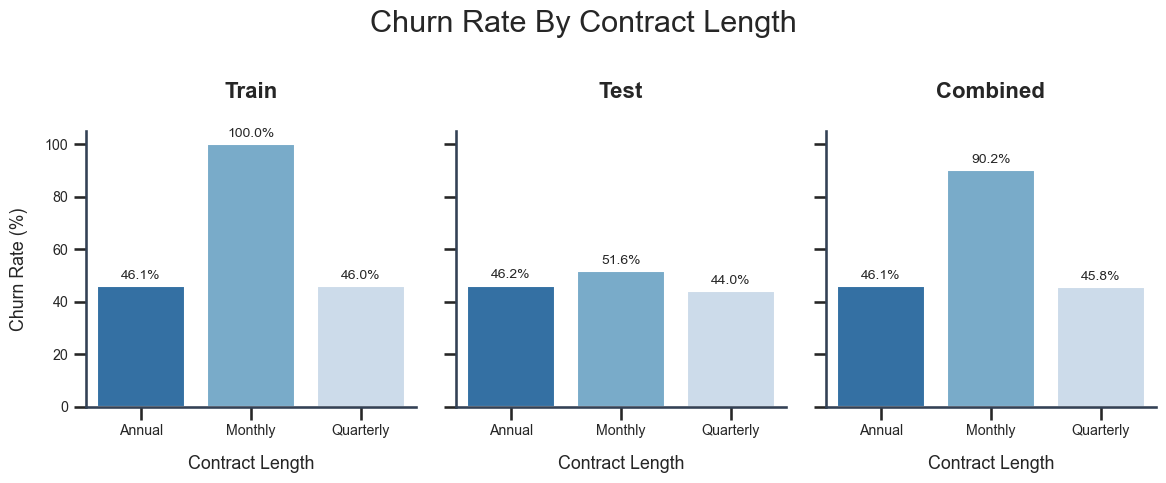

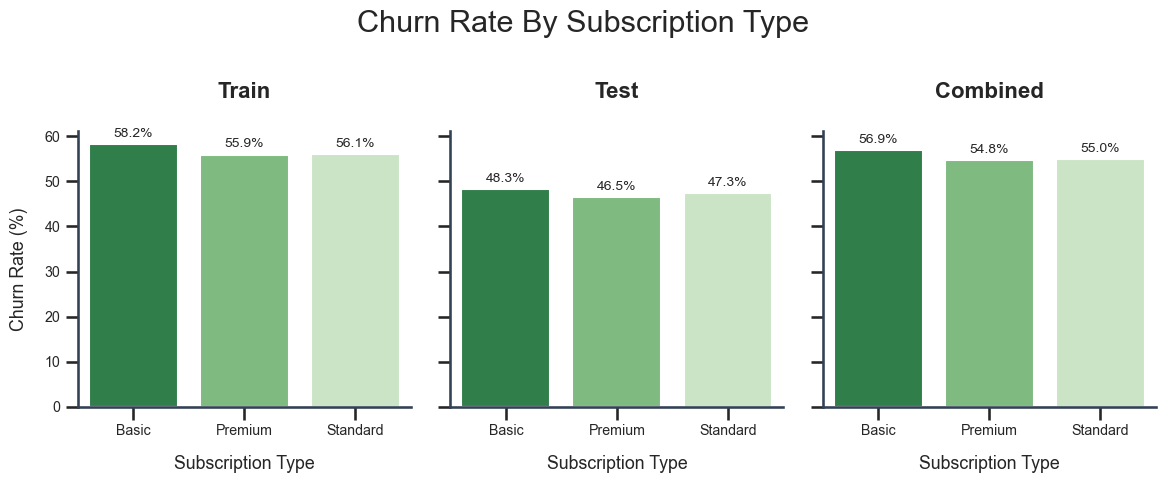

In [12]:
plot_churn_by_contract(combined_df)
plot_churn_by_subscription(combined_df)

array([<Axes: title={'center': 'Train'}, xlabel='Tenure Months', ylabel='Churn Rate (%)'>,
       <Axes: title={'center': 'Test'}, xlabel='Tenure Months'>,
       <Axes: title={'center': 'Combined'}, xlabel='Tenure Months'>],
      dtype=object)

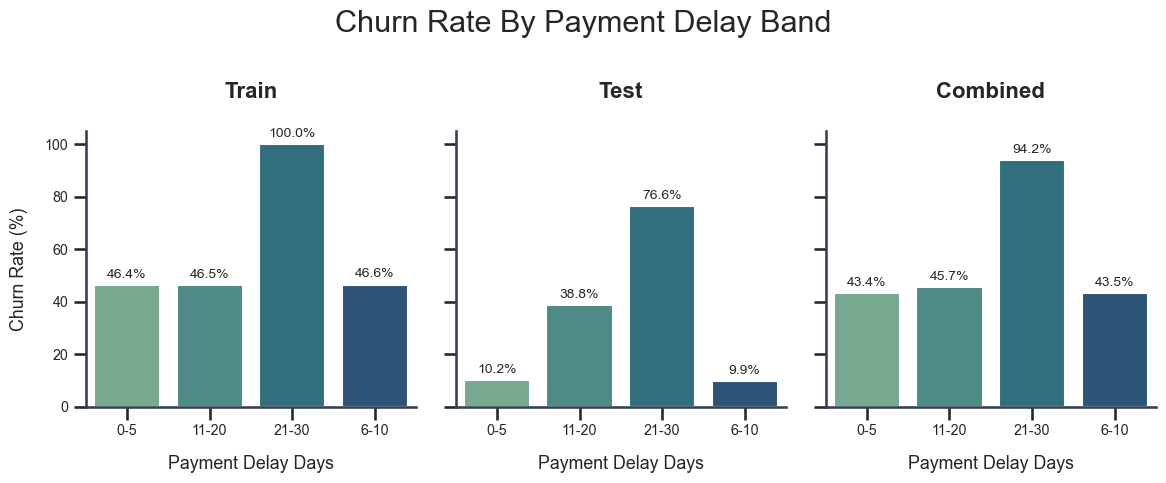

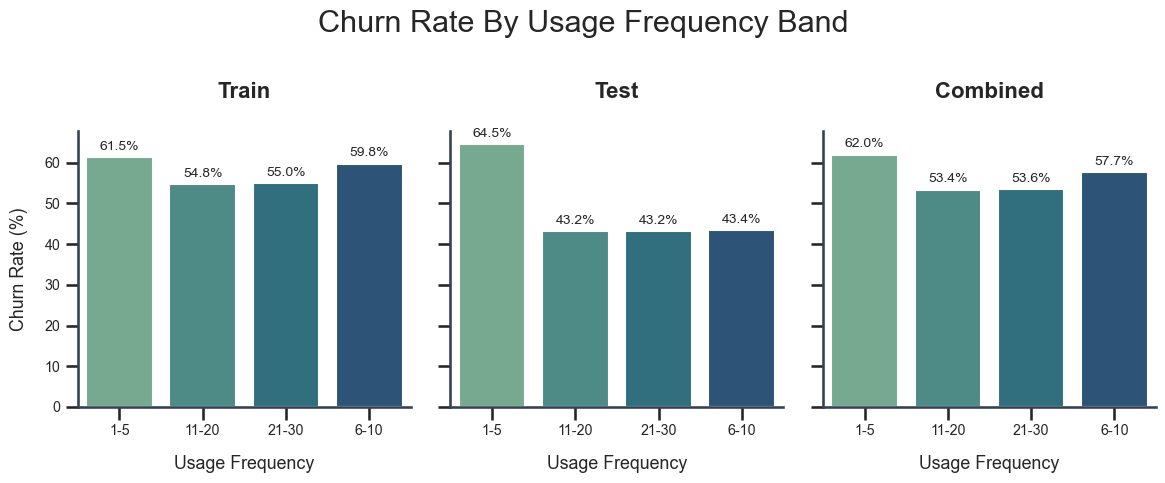

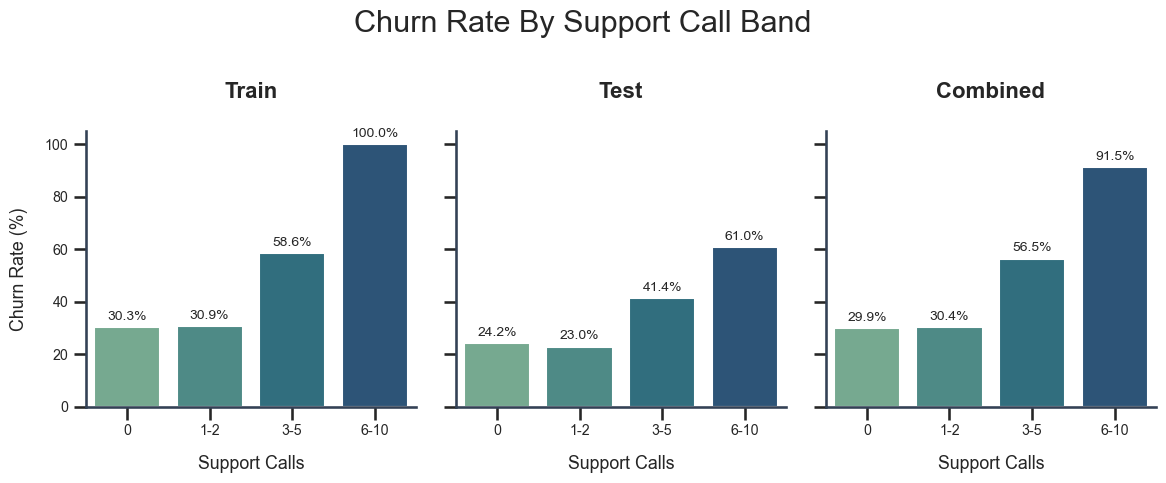

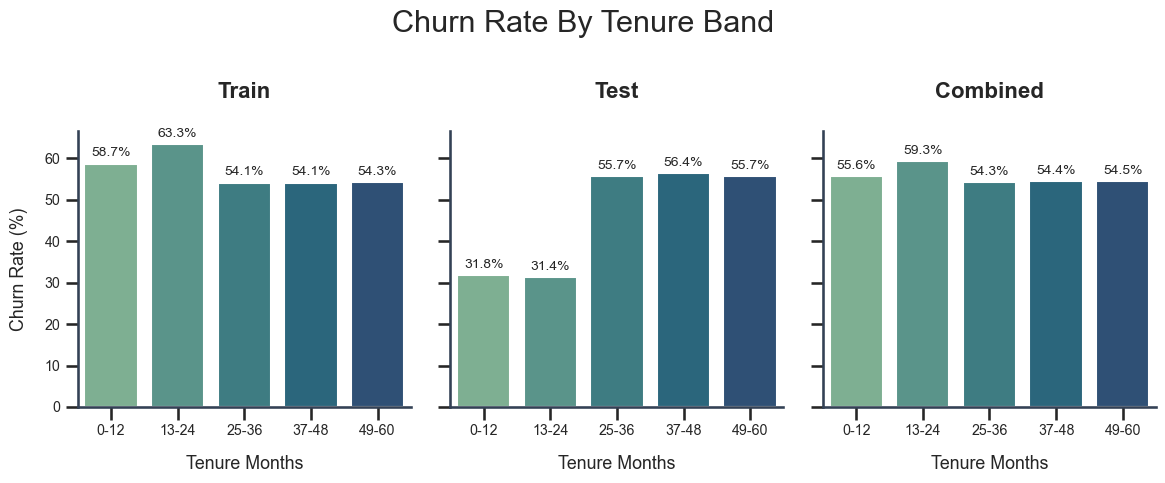

In [13]:
plot_churn_rate_by_numeric_bins(combined_df, "payment_delay_days", bins=[-1, 5, 10, 20, 30], labels=["0-5", "6-10", "11-20", "21-30"], title="Churn Rate By Payment Delay Band")
plot_churn_rate_by_numeric_bins(combined_df, "usage_frequency", bins=[0, 5, 10, 20, 30], labels=["1-5", "6-10", "11-20", "21-30"], title="Churn Rate By Usage Frequency Band")
plot_churn_rate_by_numeric_bins(combined_df, "support_calls", bins=[-1, 0, 2, 5, 10], labels=["0", "1-2", "3-5", "6-10"], title="Churn Rate By Support Call Band")
plot_churn_rate_by_numeric_bins(combined_df, "tenure_months", bins=[0, 12, 24, 36, 48, 60], labels=["0-12", "13-24", "25-36", "37-48", "49-60"], title="Churn Rate By Tenure Band")

## 7. Numeric Drivers

These views compare churned and retained customers directly, which helps separate business patterns from simple class-balance effects.

In [14]:
numeric_feature_summary(combined_df)

,churn_label,age,tenure_months,usage_frequency,support_calls,payment_delay_days,total_spend,last_interaction_days
0,Churned,41.870,31.020,15.300,5.280,15.990,538.900,15.590
1,Retained,37.000,31.760,16.230,2.030,10.380,721.390,13.390


In [15]:
correlation_table(combined_df)

support_calls            0.516
total_spend             -0.370
payment_delay_days       0.330
age                      0.191
last_interaction_days    0.127
usage_frequency         -0.053
tenure_months           -0.021
Name: churn, dtype: float64

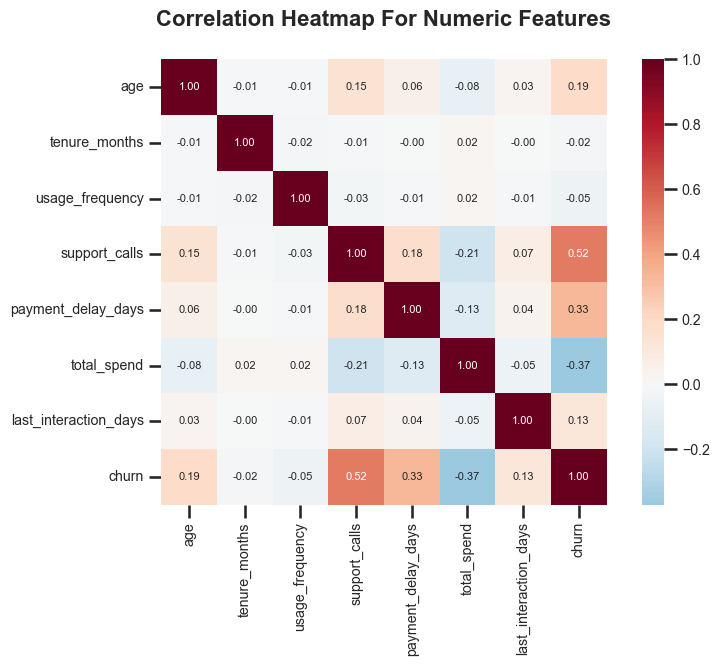

In [16]:
plot_correlation_heatmap(combined_df)

<Axes: title={'center': 'Total Spend By Churn Status'}, xlabel='Total Spend', ylabel='Churn Status'>

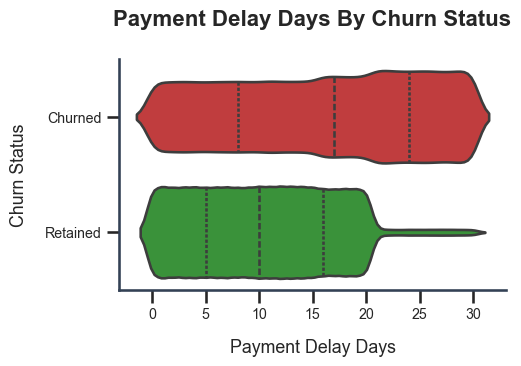

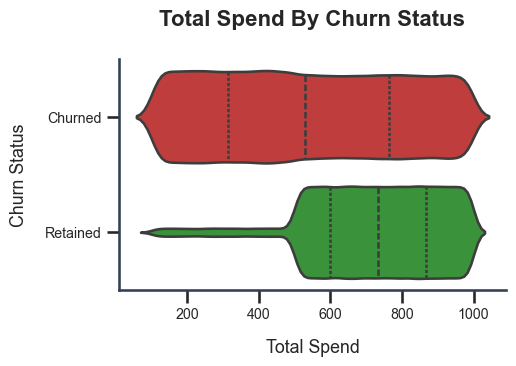

In [17]:
plot_numeric_feature_by_churn(combined_df, "payment_delay_days", kind="violin")
plot_numeric_feature_by_churn(combined_df, "total_spend", kind="violin")

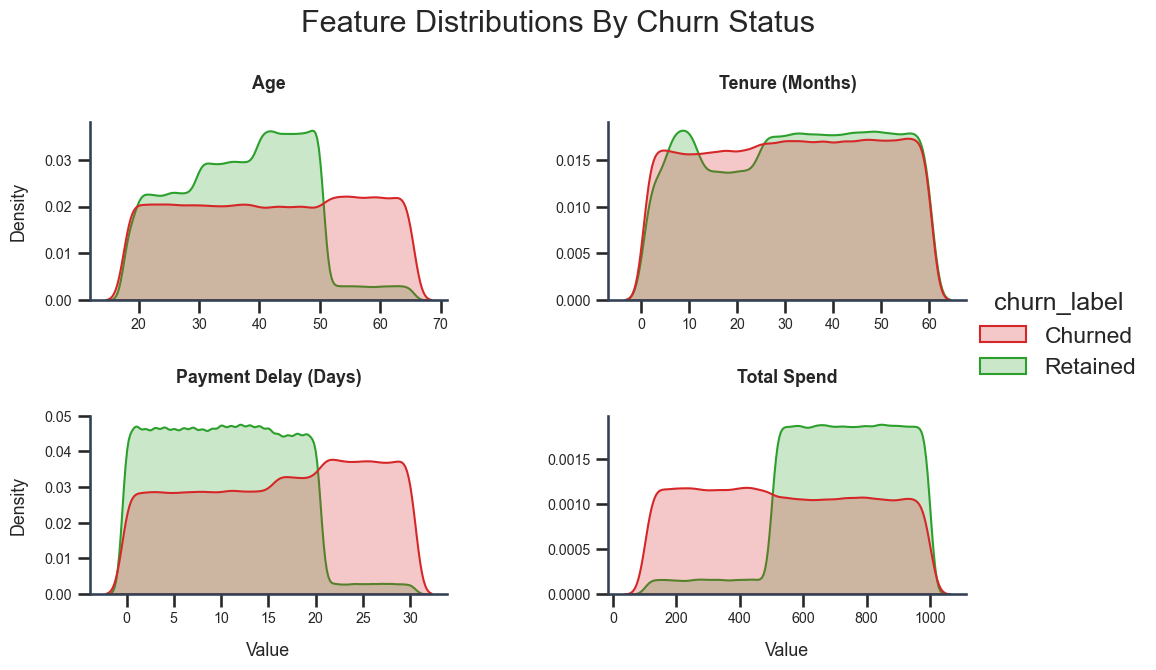

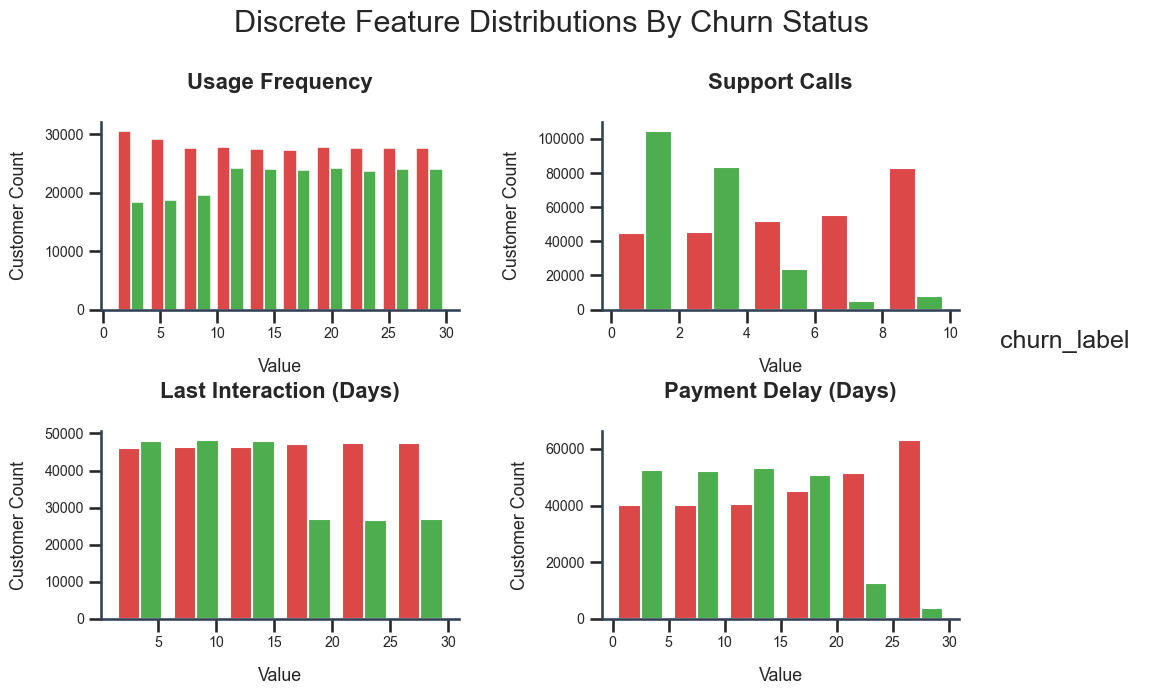

In [18]:
plot_numeric_distributions(
    combined_df,
    columns=["age", "tenure_months", "payment_delay_days", "total_spend"],
    kind="kde",
)
plot_numeric_distributions(
    combined_df,
    columns=["usage_frequency", "support_calls", "last_interaction_days", "payment_delay_days"],
    bins=[10, 5, 6, 6],
    kind="hist",
)

## 8. Interpretation

The strongest stakeholder-ready patterns in this dataset are the contract mix, payment-delay behaviour, support intensity, and churn concentration in specific customer buckets. The next step is to carry those patterns into the modelling notebook and test whether they improve predictive performance on the untouched test split.